# Part II – Vision Task: Intel  Image Classification  
 Aman Rauniyar (A)  
**University ID:** 2408454  
**Module:** 6CS012 Artificial Intelligence and Machine Learning  
**Task:** CNN from scratch, deeper regularized CNN, optimizer comparison, ablation study, and VGG16 transfer learning.



In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Setup and reproducibility

This section imports the required libraries, fixes random seeds, detects GPU availability, and prepares output folders.  
The code is written to run both in Google Colab and locally.

In [8]:
# =========================
# 1. SETUP
# =========================
import os
import time
import json
import zipfile
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import Sequential, Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import load_img, img_to_array

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Main training configuration
IMG_SIZE = (150, 150)
BATCH_SIZE = 32
NUM_CLASSES = 6

# You can increase these after confirming the notebook runs successfully.
BASELINE_EPOCHS = 12
DEEP_EPOCHS = 12
SGD_EPOCHS = 12
ABLATION_EPOCHS = 8
TL_FEATURE_EPOCHS = 8
TL_FINE_TUNE_EPOCHS = 5

OUTPUT_DIR = Path("outputs_2408454_AmanRauniyar")
FIG_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
RESULT_DIR = OUTPUT_DIR / "results"
for folder in [OUTPUT_DIR, FIG_DIR, MODEL_DIR, RESULT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

# Try to avoid GPU memory allocation issues on Colab
for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("Memory growth could not be set:", e)

TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Dataset extraction and validation

The uploaded archive is expected to contain the folder:

`Intel-Image-Classification/train`, `Intel-Image-Classification/val`, and `Intel-Image-Classification/test`.

The code below automatically finds or extracts the dataset.

In [10]:
# =========================
# 2. DATASET EXTRACTION
# =========================

def find_dataset_root():
    candidate_roots = [
        Path("/content/my_dataset/Intel-Image-Classification"),
        Path("/content/Intel-Image-Classification"),
        Path("my_dataset/Intel-Image-Classification"),
        Path("Intel-Image-Classification"),
        Path("/mnt/data/intel_dataset/Intel-Image-Classification"),  # local sandbox fallback
    ]
    for root in candidate_roots:
        if (root / "train").exists() and (root / "val").exists() and (root / "test").exists():
            return root
    return None

def extract_archive_if_needed():
    dataset_root = find_dataset_root()
    if dataset_root is not None:
        print("Dataset already found at:", dataset_root)
        return dataset_root

    archive_candidates = [
        Path("/content/drive/MyDrive/archive.zip"),
        Path("/content/archive.zip"),
        Path("archive.zip"),
        Path("/mnt/data/archive.zip"),  # local sandbox fallback
    ]

    archive_path = None
    for candidate in archive_candidates:
        if candidate.exists():
            archive_path = candidate
            break

    if archive_path is None:
        raise FileNotFoundError(
            "archive.zip was not found. Upload it to Colab as /content/archive.zip "
            "or keep it in Google Drive as /content/drive/MyDrive/archive.zip."
        )

    extract_to = Path("/content/my_dataset") if Path("/content").exists() else Path("my_dataset")
    extract_to.mkdir(parents=True, exist_ok=True)
    print(f"Extracting {archive_path} to {extract_to} ...")
    with zipfile.ZipFile(archive_path, "r") as z:
        bad_file = z.testzip()
        if bad_file is not None:
            raise zipfile.BadZipFile(f"Corrupted file inside zip: {bad_file}")
        z.extractall(extract_to)

    dataset_root = find_dataset_root()
    if dataset_root is None:
        raise FileNotFoundError("Dataset folder not found after extraction. Check archive structure.")
    print("Dataset extracted and found at:", dataset_root)
    return dataset_root

DATASET_ROOT = extract_archive_if_needed()
train_dir = DATASET_ROOT / "train"
val_dir = DATASET_ROOT / "val"
test_dir = DATASET_ROOT / "test"

print("Train:", train_dir)
print("Validation:", val_dir)
print("Test:", test_dir)

Extracting /content/drive/MyDrive/archive.zip to /content/my_dataset ...
Dataset extracted and found at: /content/my_dataset/Intel-Image-Classification
Train: /content/my_dataset/Intel-Image-Classification/train
Validation: /content/my_dataset/Intel-Image-Classification/val
Test: /content/my_dataset/Intel-Image-Classification/test


## 3. Dataset understanding, class counts, and visualisation

This section answers the required dataset-understanding questions:
- What the dataset represents
- Total number of images
- Class distribution
- Existing train/validation/test split
- Sample images from each class

,split,class,count
0,train,buildings,1972
1,train,forest,2044
2,train,glacier,2164
3,train,mountain,2261
4,train,sea,2047
5,train,street,2144
6,val,buildings,219
7,val,forest,227
8,val,glacier,240
9,val,mountain,251


Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Total images: 17034
split
test      3000
train    12632
val       1402
Name: count, dtype: int64


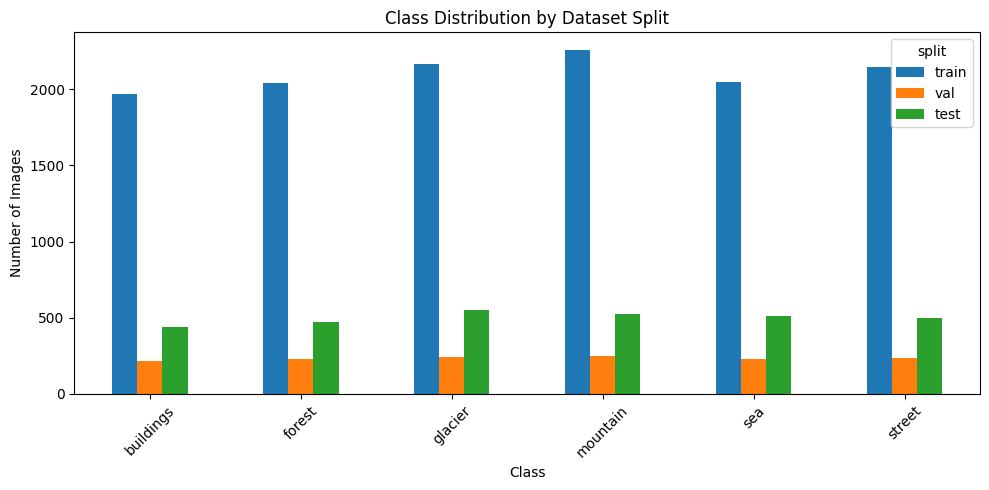

In [11]:
# =========================
# 3. DATASET ANALYSIS
# =========================

VALID_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def count_images_by_split(root):
    rows = []
    for split in ["train", "val", "test"]:
        split_path = root / split
        for class_dir in sorted([p for p in split_path.iterdir() if p.is_dir()]):
            n = sum(1 for f in class_dir.rglob("*") if f.suffix.lower() in VALID_EXTS)
            rows.append({"split": split, "class": class_dir.name, "count": n})
    return pd.DataFrame(rows)

dataset_counts = count_images_by_split(DATASET_ROOT)
class_names = sorted(dataset_counts["class"].unique().tolist())
NUM_CLASSES = len(class_names)

display(dataset_counts)
print("Classes:", class_names)
print("Total images:", int(dataset_counts["count"].sum()))
print(dataset_counts.groupby("split")["count"].sum())

dataset_counts.to_csv(RESULT_DIR / "dataset_class_distribution.csv", index=False)

# Plot class distribution
pivot_counts = dataset_counts.pivot(index="class", columns="split", values="count").fillna(0)
ax = pivot_counts[["train", "val", "test"]].plot(kind="bar", figsize=(10, 5))
plt.title("Class Distribution by Dataset Split")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution.png", dpi=150)
plt.show()

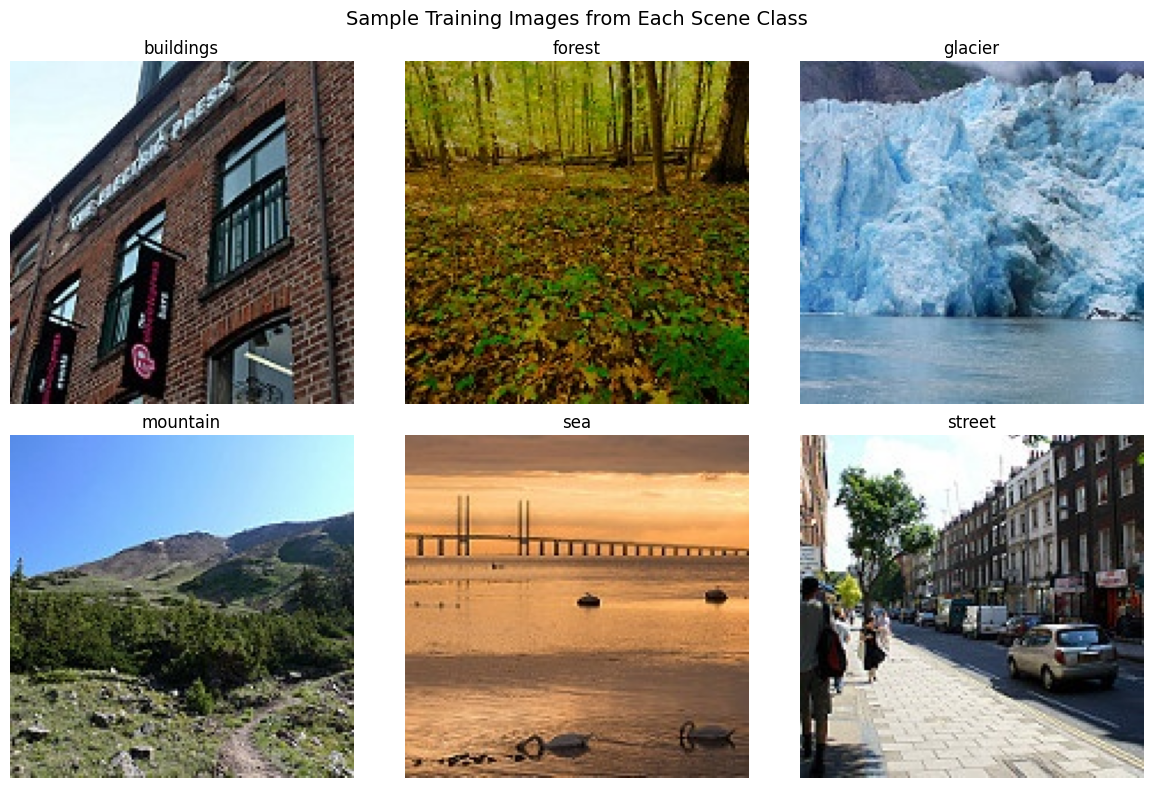

In [12]:
# Display sample images from each class
plt.figure(figsize=(12, 8))
plot_index = 1

for class_name in class_names:
    image_files = sorted([p for p in (train_dir / class_name).iterdir() if p.suffix.lower() in VALID_EXTS])
    if not image_files:
        continue
    sample_path = random.choice(image_files)
    image = load_img(sample_path, target_size=IMG_SIZE)
    plt.subplot(2, 3, plot_index)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")
    plot_index += 1

plt.suptitle("Sample Training Images from Each Scene Class", fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "sample_images_by_class.png", dpi=150)
plt.show()

## 4. Data generators and preprocessing

For the CNNs trained from scratch:
- Images are resized to **150 × 150**
- Pixel values are normalised using `rescale=1./255`
- Training images use augmentation: rotation, shift, shear, zoom, and horizontal flip
- Validation and test images are not augmented

The validation and test generators use `shuffle=False` so that labels and predictions remain aligned for evaluation.

In [13]:
# =========================
# 4. DATA GENERATORS FOR SCRATCH CNN MODELS
# =========================

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

eval_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_generator = eval_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

test_generator = eval_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_indices = train_generator.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}
print("Class indices:", class_indices)

with open(RESULT_DIR / "class_indices.json", "w") as f:
    json.dump(class_indices, f, indent=4)

Found 12632 images belonging to 6 classes.
Found 1402 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.
Class indices: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}


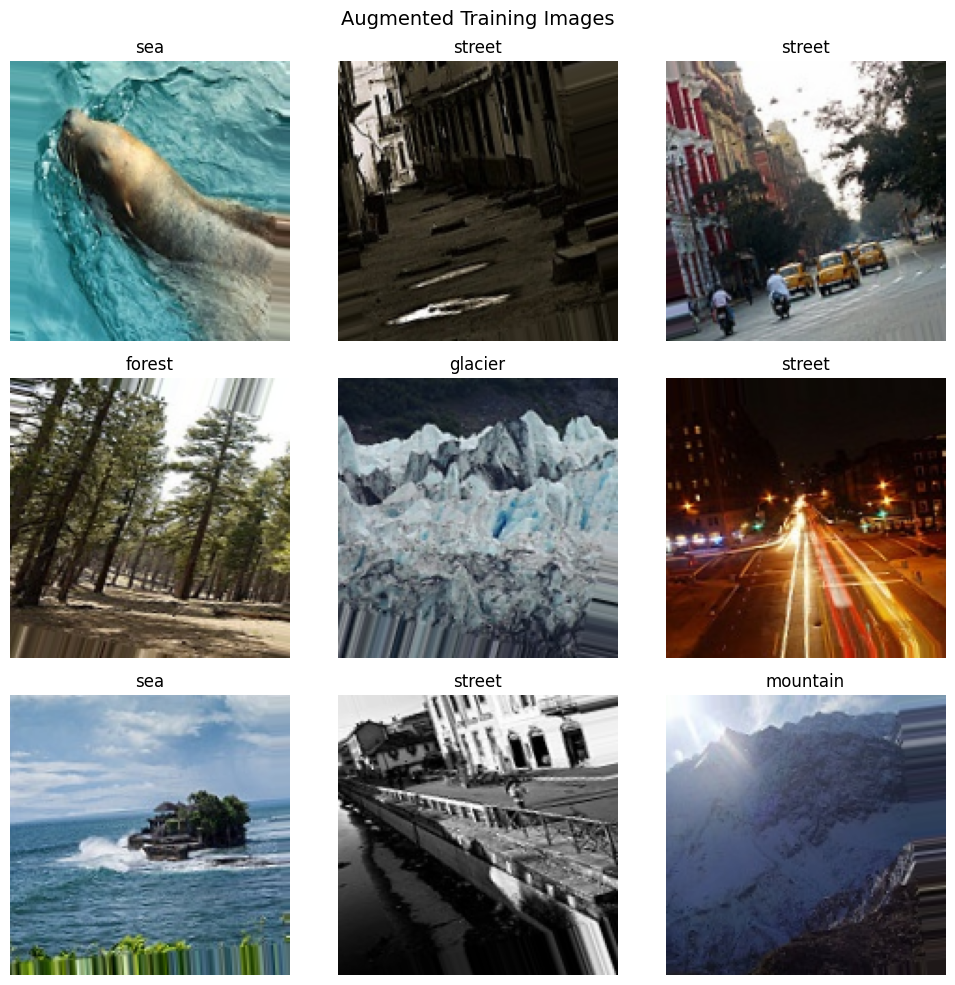

In [14]:
# Visualise augmented images
images, labels = next(train_generator)
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    label = idx_to_class[int(np.argmax(labels[i]))]
    plt.title(label)
    plt.axis("off")
plt.suptitle("Augmented Training Images", fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "augmented_training_images.png", dpi=150)
plt.show()

## 5. Reusable training and evaluation functions

In [15]:
# =========================
# 5. HELPER FUNCTIONS
# =========================

training_times = {}
results = []

def make_callbacks(model_name):
    checkpoint_path = MODEL_DIR / f"{model_name}_best.keras"
    return [
        ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
            verbose=1
        ),
        EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=2,
            min_lr=1e-7,
            verbose=1
        )
    ]

def train_and_time(model, model_name, train_gen, val_gen, epochs):
    start = time.time()
    history = model.fit(
        train_gen,
        epochs=epochs,
        validation_data=val_gen,
        callbacks=make_callbacks(model_name),
        verbose=1
    )
    elapsed = time.time() - start
    training_times[model_name] = elapsed
    model.save(MODEL_DIR / f"{model_name}_final.keras")
    print(f"{model_name} training time: {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")
    return history

def plot_training_curves(history, model_name):
    history_df = pd.DataFrame(history.history)
    history_df.to_csv(RESULT_DIR / f"{model_name}_history.csv", index=False)

    epochs = range(1, len(history_df) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history_df["accuracy"], label="Training Accuracy")
    plt.plot(epochs, history_df["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name}: Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{model_name}_accuracy_curve.png", dpi=150)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history_df["loss"], label="Training Loss")
    plt.plot(epochs, history_df["val_loss"], label="Validation Loss")
    plt.title(f"{model_name}: Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{model_name}_loss_curve.png", dpi=150)
    plt.show()

def evaluate_model(model, generator, model_name):
    generator.reset()
    probs = model.predict(generator, verbose=1)
    y_pred = np.argmax(probs, axis=1)
    y_true = generator.classes
    labels = list(generator.class_indices.keys())

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

    print(f"\n===== {model_name} Evaluation =====")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=labels, zero_division=0))

    # Save classification report
    report_dict = classification_report(
        y_true, y_pred, target_names=labels, zero_division=0, output_dict=True
    )
    pd.DataFrame(report_dict).transpose().to_csv(RESULT_DIR / f"{model_name}_classification_report.csv")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap="Blues", values_format="d", xticks_rotation=45)
    plt.title(f"{model_name}: Confusion Matrix")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{model_name}_confusion_matrix.png", dpi=150)
    plt.show()

    # Save predictions
    pred_df = pd.DataFrame({
        "filepath": generator.filepaths,
        "true_label": [labels[i] for i in y_true],
        "predicted_label": [labels[i] for i in y_pred],
        "correct": y_true == y_pred
    })
    pred_df.to_csv(RESULT_DIR / f"{model_name}_predictions.csv", index=False)

    row = {
        "model": model_name,
        "test_accuracy": acc,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1,
        "training_time_seconds": training_times.get(model_name, np.nan),
        "training_time_minutes": training_times.get(model_name, np.nan) / 60 if model_name in training_times else np.nan
    }
    results.append(row)
    return row, pred_df

def print_model_size(model, model_name):
    trainable = np.sum([np.prod(v.shape) for v in model.trainable_weights])
    non_trainable = np.sum([np.prod(v.shape) for v in model.non_trainable_weights])
    print(f"{model_name} trainable parameters: {trainable:,}")
    print(f"{model_name} non-trainable parameters: {non_trainable:,}")

## 6. Baseline CNN from scratch

Required baseline structure:
- 3 convolutional layers
- Pooling after each convolutional layer
- 3 fully connected dense layers
- Softmax output layer for 6-class classification

In [16]:
# =========================
# 6. BASELINE CNN
# =========================

def build_baseline_cnn(input_shape=(150, 150, 3), num_classes=6):
    model = Sequential([
        Input(shape=input_shape),

        Conv2D(32, (3, 3), activation="relu", padding="same", name="conv_1"),
        MaxPooling2D((2, 2), name="pool_1"),

        Conv2D(64, (3, 3), activation="relu", padding="same", name="conv_2"),
        MaxPooling2D((2, 2), name="pool_2"),

        Conv2D(128, (3, 3), activation="relu", padding="same", name="conv_3"),
        MaxPooling2D((2, 2), name="pool_3"),

        Flatten(name="flatten"),

        Dense(256, activation="relu", name="fc_1"),
        Dense(128, activation="relu", name="fc_2"),
        Dense(64, activation="relu", name="fc_3"),

        Dense(num_classes, activation="softmax", name="output")
    ])

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

baseline_model = build_baseline_cnn(input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES)
baseline_model.summary()
print_model_size(baseline_model, "baseline_cnn")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_3 (MaxPooling2D)           │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_1 (Dense)                    │ (None, 256)            │    10,617,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_2 (Dense)                    │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_3 (Dense)                    │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,751,878 (41.02 MB)

 Trainable params: 10,751,878 (41.02 MB)

 Non-trainable params: 0 (0.00 B)

baseline_cnn trainable parameters: 10,751,878
baseline_cnn non-trainable parameters: 0.0


Epoch 1/12
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.4949 - loss: 1.2701
Epoch 1: val_accuracy improved from None to 0.67190, saving model to outputs_2408454_AmanRauniyar/models/baseline_cnn_best.keras

Epoch 1: finished saving model to outputs_2408454_AmanRauniyar/models/baseline_cnn_best.keras
395/395 ━━━━━━━━━━━━━━━━━━━━ 101s 236ms/step - accuracy: 0.5695 - loss: 1.0891 - val_accuracy: 0.6719 - val_loss: 0.8348 - learning_rate: 0.0010
Epoch 2/12
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.6648 - loss: 0.8743
Epoch 2: val_accuracy improved from 0.67190 to 0.76034, saving model to outputs_2408454_AmanRauniyar/models/baseline_cnn_best.keras

Epoch 2: finished saving model to outputs_2408454_AmanRauniyar/models/baseline_cnn_best.keras
395/395 ━━━━━━━━━━━━━━━━━━━━ 85s 215ms/step - accuracy: 0.6947 - loss: 0.8187 - val_accuracy: 0.7603 - val_loss: 0.6593 - learning_rate: 0.0010
Epoch 3/12
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.7468 - loss: 0.6

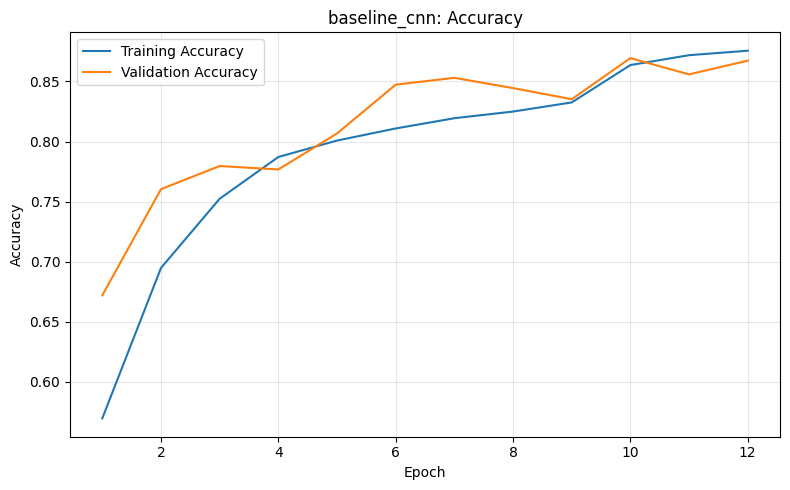

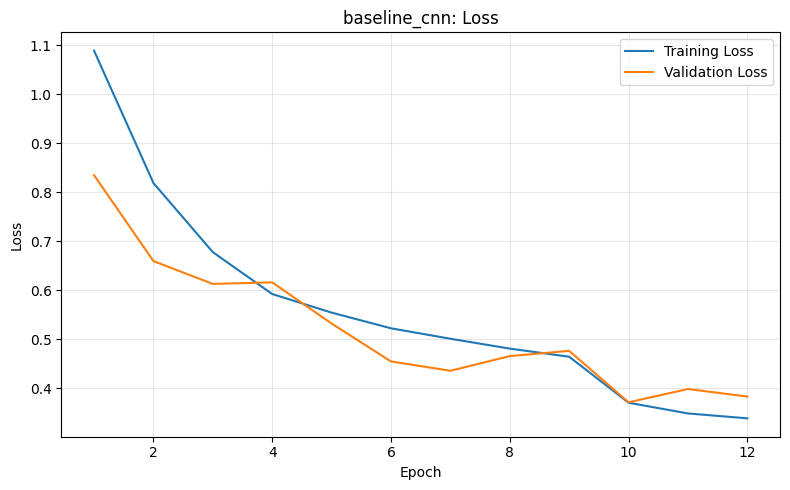

94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step

===== baseline_cnn Evaluation =====
Accuracy:  0.8667
Precision: 0.8669
Recall:    0.8700
F1-score:  0.8680

              precision    recall  f1-score   support

   buildings       0.83      0.89      0.86       437
      forest       0.95      0.98      0.97       474
     glacier       0.84      0.80      0.82       553
    mountain       0.83      0.79      0.81       525
         sea       0.86      0.87      0.87       510
      street       0.89      0.88      0.89       501

    accuracy                           0.87      3000
   macro avg       0.87      0.87      0.87      3000
weighted avg       0.87      0.87      0.87      3000



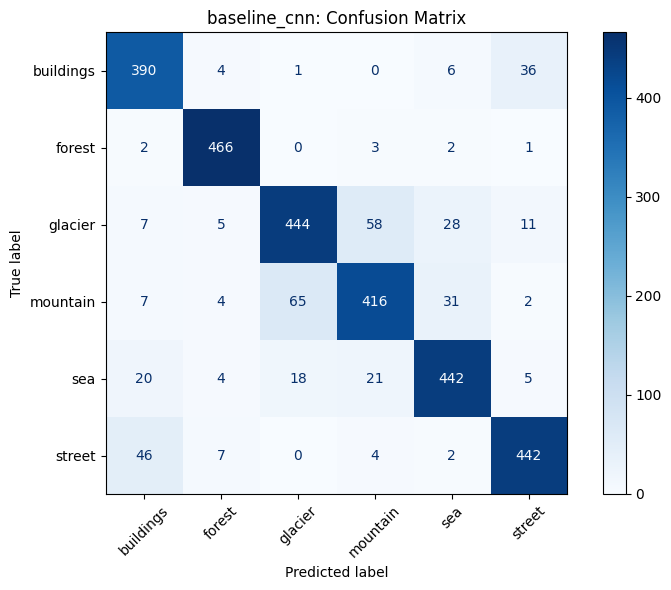

In [17]:
baseline_history = train_and_time(
    baseline_model,
    "baseline_cnn",
    train_generator,
    val_generator,
    BASELINE_EPOCHS
)

plot_training_curves(baseline_history, "baseline_cnn")
baseline_metrics, baseline_predictions = evaluate_model(baseline_model, test_generator, "baseline_cnn")

## 7. Deeper CNN with regularisation

This model doubles the convolutional depth of the baseline by using **6 convolutional layers**.  
It also adds **Batch Normalization** and **Dropout** to improve training stability and reduce overfitting.

In [18]:
# =========================
# 7. DEEPER CNN WITH REGULARISATION
# =========================

def build_deeper_cnn(
    input_shape=(150, 150, 3),
    num_classes=6,
    optimizer="adam",
    use_batchnorm=True,
    use_dropout=True
):
    model = Sequential()
    model.add(Input(shape=input_shape))

    # Block 1: 2 convolutional layers
    model.add(Conv2D(32, (3, 3), activation="relu", padding="same", name="block1_conv1"))
    model.add(Conv2D(32, (3, 3), activation="relu", padding="same", name="block1_conv2"))
    if use_batchnorm:
        model.add(BatchNormalization(name="block1_bn"))
    model.add(MaxPooling2D((2, 2), name="block1_pool"))
    if use_dropout:
        model.add(Dropout(0.25, name="block1_dropout"))

    # Block 2: 2 convolutional layers
    model.add(Conv2D(64, (3, 3), activation="relu", padding="same", name="block2_conv1"))
    model.add(Conv2D(64, (3, 3), activation="relu", padding="same", name="block2_conv2"))
    if use_batchnorm:
        model.add(BatchNormalization(name="block2_bn"))
    model.add(MaxPooling2D((2, 2), name="block2_pool"))
    if use_dropout:
        model.add(Dropout(0.30, name="block2_dropout"))

    # Block 3: 2 convolutional layers
    model.add(Conv2D(128, (3, 3), activation="relu", padding="same", name="block3_conv1"))
    model.add(Conv2D(128, (3, 3), activation="relu", padding="same", name="block3_conv2"))
    if use_batchnorm:
        model.add(BatchNormalization(name="block3_bn"))
    model.add(MaxPooling2D((2, 2), name="block3_pool"))
    if use_dropout:
        model.add(Dropout(0.40, name="block3_dropout"))

    model.add(Flatten(name="flatten"))

    model.add(Dense(512, activation="relu", name="fc_1"))
    if use_batchnorm:
        model.add(BatchNormalization(name="fc_1_bn"))
    if use_dropout:
        model.add(Dropout(0.50, name="fc_1_dropout"))

    model.add(Dense(256, activation="relu", name="fc_2"))
    if use_dropout:
        model.add(Dropout(0.30, name="fc_2_dropout"))

    model.add(Dense(128, activation="relu", name="fc_3"))
    model.add(Dense(num_classes, activation="softmax", name="output"))

    if optimizer == "adam":
        opt = Adam(learning_rate=1e-3)
    elif optimizer == "sgd":
        opt = SGD(learning_rate=1e-2, momentum=0.9, nesterov=True)
    else:
        raise ValueError("optimizer must be either 'adam' or 'sgd'")

    model.compile(
        optimizer=opt,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

deep_adam_model = build_deeper_cnn(
    input_shape=(*IMG_SIZE, 3),
    num_classes=NUM_CLASSES,
    optimizer="adam",
    use_batchnorm=True,
    use_dropout=True
)

deep_adam_model.summary()
print_model_size(deep_adam_model, "deep_cnn_adam")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn (BatchNormalization)  │ (None, 150, 150, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_dropout (Dropout)        │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn (BatchNormalization)  │ (None, 75, 75, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_dropout (Dropout)        │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn (BatchNormalization)  │ (None, 37, 37, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_dropout (Dropout)        │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_1 (Dense)                    │ (None, 512)            │    21,234,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_1_bn (BatchNormalization)    │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_1_dropout (Dropout)          │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_2 (Dense)                    │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_2_dropout (Dropout)          │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_3 (Dense)                    │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,689,126 (82.74 MB)

 Trainable params: 21,687,654 (82.73 MB)

 Non-trainable params: 1,472 (5.75 KB)

deep_cnn_adam trainable parameters: 21,687,654
deep_cnn_adam non-trainable parameters: 1,472


Epoch 1/12
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.4756 - loss: 1.4103
Epoch 1: val_accuracy improved from None to 0.27033, saving model to outputs_2408454_AmanRauniyar/models/deep_cnn_adam_best.keras

Epoch 1: finished saving model to outputs_2408454_AmanRauniyar/models/deep_cnn_adam_best.keras
395/395 ━━━━━━━━━━━━━━━━━━━━ 130s 280ms/step - accuracy: 0.5507 - loss: 1.1709 - val_accuracy: 0.2703 - val_loss: 2.0343 - learning_rate: 0.0010
Epoch 2/12
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - accuracy: 0.6487 - loss: 0.9288
Epoch 2: val_accuracy improved from 0.27033 to 0.59272, saving model to outputs_2408454_AmanRauniyar/models/deep_cnn_adam_best.keras

Epoch 2: finished saving model to outputs_2408454_AmanRauniyar/models/deep_cnn_adam_best.keras
395/395 ━━━━━━━━━━━━━━━━━━━━ 96s 242ms/step - accuracy: 0.6657 - loss: 0.8886 - val_accuracy: 0.5927 - val_loss: 1.2109 - learning_rate: 0.0010
Epoch 3/12
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - accuracy: 0.7149 - loss:

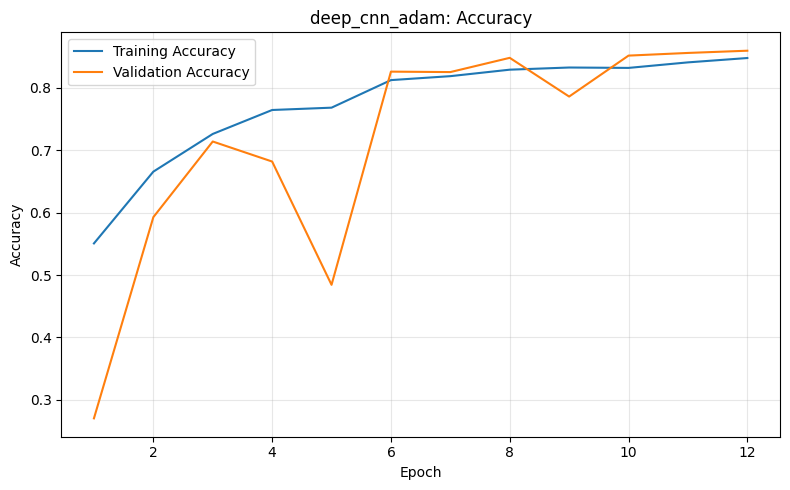

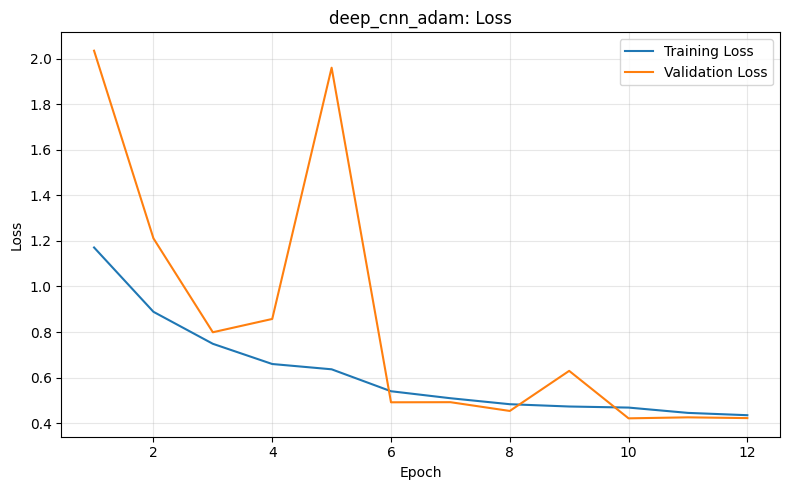

94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step

===== deep_cnn_adam Evaluation =====
Accuracy:  0.8647
Precision: 0.8669
Recall:    0.8652
F1-score:  0.8648

              precision    recall  f1-score   support

   buildings       0.89      0.81      0.85       437
      forest       0.92      0.98      0.95       474
     glacier       0.82      0.87      0.84       553
    mountain       0.86      0.76      0.81       525
         sea       0.86      0.89      0.87       510
      street       0.86      0.89      0.87       501

    accuracy                           0.86      3000
   macro avg       0.87      0.87      0.86      3000
weighted avg       0.86      0.86      0.86      3000



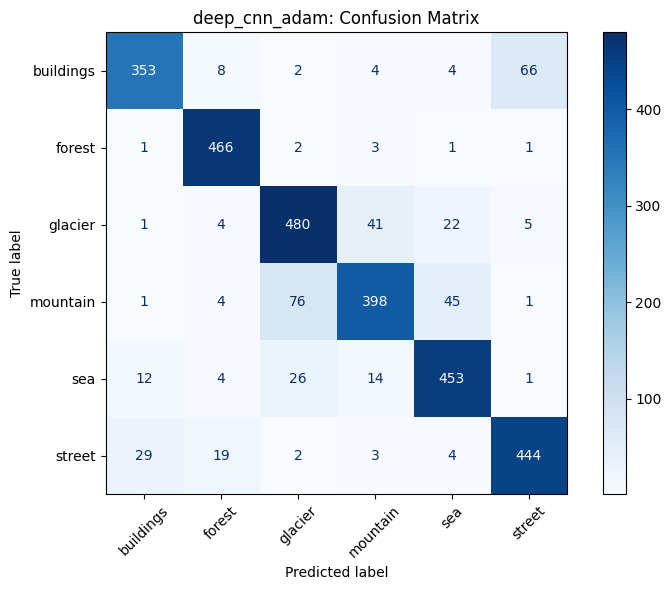

In [19]:
deep_adam_history = train_and_time(
    deep_adam_model,
    "deep_cnn_adam",
    train_generator,
    val_generator,
    DEEP_EPOCHS
)

plot_training_curves(deep_adam_history, "deep_cnn_adam")
deep_adam_metrics, deep_adam_predictions = evaluate_model(deep_adam_model, test_generator, "deep_cnn_adam")

## 8. Optimizer comparison: SGD vs Adam

This section trains the same deeper CNN architecture using SGD with momentum.  
The result is compared with the Adam-trained deeper CNN.

In [20]:
# =========================
# 8. OPTIMIZER COMPARISON: SGD
# =========================

deep_sgd_model = build_deeper_cnn(
    input_shape=(*IMG_SIZE, 3),
    num_classes=NUM_CLASSES,
    optimizer="sgd",
    use_batchnorm=True,
    use_dropout=True
)

deep_sgd_model.summary()
print_model_size(deep_sgd_model, "deep_cnn_sgd")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn (BatchNormalization)  │ (None, 150, 150, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_dropout (Dropout)        │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn (BatchNormalization)  │ (None, 75, 75, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_dropout (Dropout)        │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn (BatchNormalization)  │ (None, 37, 37, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_dropout (Dropout)        │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_1 (Dense)                    │ (None, 512)            │    21,234,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_1_bn (BatchNormalization)    │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_1_dropout (Dropout)          │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_2 (Dense)                    │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_2_dropout (Dropout)          │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_3 (Dense)                    │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,689,126 (82.74 MB)

 Trainable params: 21,687,654 (82.73 MB)

 Non-trainable params: 1,472 (5.75 KB)

deep_cnn_sgd trainable parameters: 21,687,654
deep_cnn_sgd non-trainable parameters: 1,472


Epoch 1/12
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.4442 - loss: 1.4682
Epoch 1: val_accuracy improved from None to 0.59272, saving model to outputs_2408454_AmanRauniyar/models/deep_cnn_sgd_best.keras

Epoch 1: finished saving model to outputs_2408454_AmanRauniyar/models/deep_cnn_sgd_best.keras
395/395 ━━━━━━━━━━━━━━━━━━━━ 113s 263ms/step - accuracy: 0.5074 - loss: 1.2559 - val_accuracy: 0.5927 - val_loss: 1.0651 - learning_rate: 0.0100
Epoch 2/12
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.5882 - loss: 1.0577
Epoch 2: val_accuracy did not improve from 0.59272
395/395 ━━━━━━━━━━━━━━━━━━━━ 95s 239ms/step - accuracy: 0.5914 - loss: 1.0490 - val_accuracy: 0.4208 - val_loss: 1.4568 - learning_rate: 0.0100
Epoch 3/12
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.6135 - loss: 0.9886
Epoch 3: val_accuracy improved from 0.59272 to 0.62268, saving model to outputs_2408454_AmanRauniyar/models/deep_cnn_sgd_best.keras

Epoch 3: finished saving model to outpu

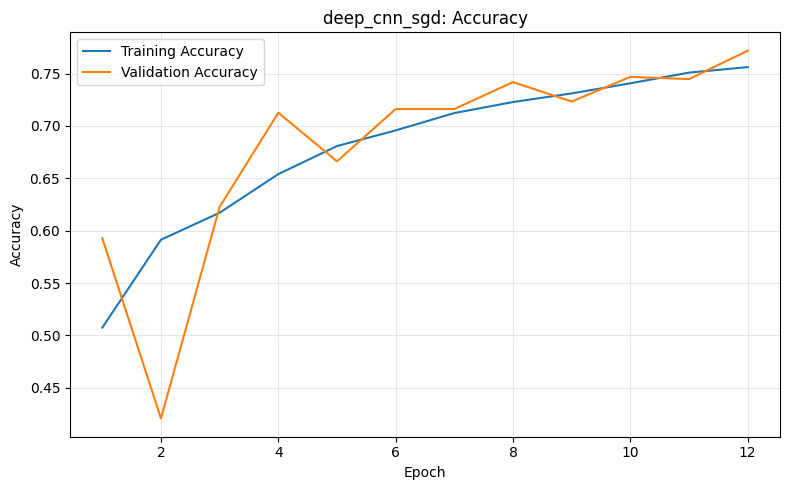

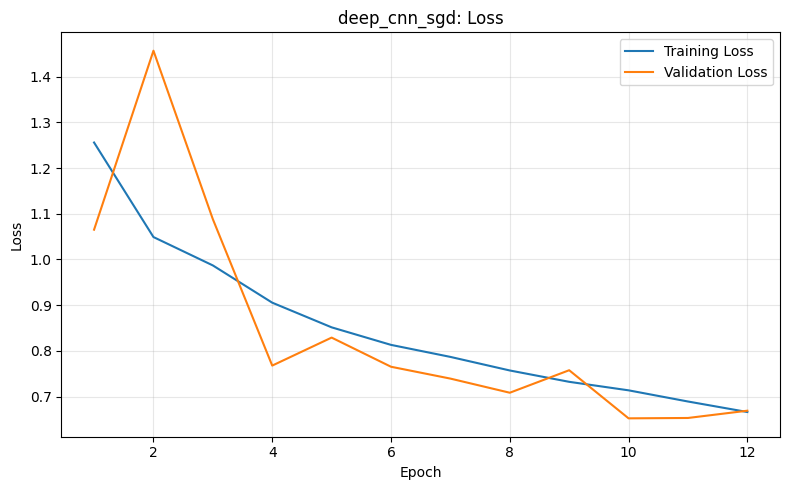

94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step

===== deep_cnn_sgd Evaluation =====
Accuracy:  0.7573
Precision: 0.7774
Recall:    0.7600
F1-score:  0.7606

              precision    recall  f1-score   support

   buildings       0.77      0.70      0.73       437
      forest       0.92      0.93      0.93       474
     glacier       0.77      0.59      0.67       553
    mountain       0.58      0.85      0.69       525
         sea       0.81      0.65      0.72       510
      street       0.82      0.84      0.83       501

    accuracy                           0.76      3000
   macro avg       0.78      0.76      0.76      3000
weighted avg       0.77      0.76      0.76      3000



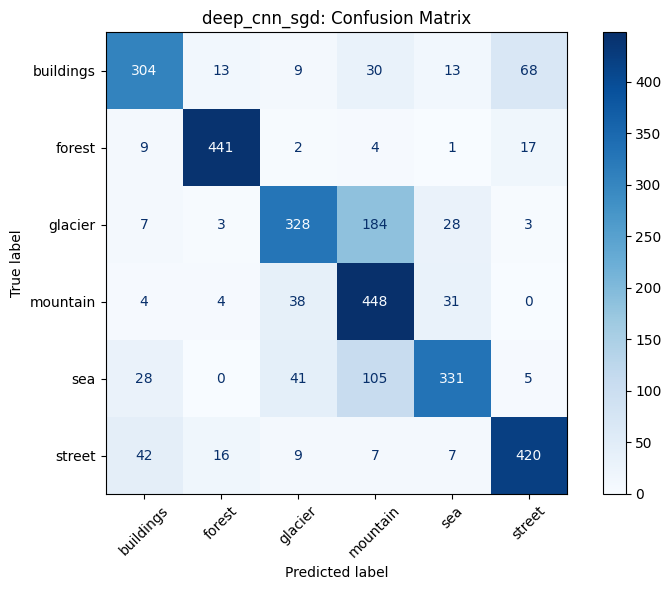

In [32]:
deep_sgd_history = train_and_time(
    deep_sgd_model,
    "deep_cnn_sgd",
    train_generator,
    val_generator,
    SGD_EPOCHS
)

plot_training_curves(deep_sgd_history, "deep_cnn_sgd")
deep_sgd_metrics, deep_sgd_predictions = evaluate_model(deep_sgd_model, test_generator, "deep_cnn_sgd")

## 9. Ablation study: deeper CNN without Dropout

This experiment removes one regularisation component, **Dropout**, while keeping the deeper architecture and Batch Normalization.  
Compare this with `deep_cnn_adam` to discuss whether Dropout improved generalisation or not.

In [21]:
# =========================
# 9. ABLATION STUDY: REMOVE DROPOUT
# =========================

deep_no_dropout_model = build_deeper_cnn(
    input_shape=(*IMG_SIZE, 3),
    num_classes=NUM_CLASSES,
    optimizer="adam",
    use_batchnorm=True,
    use_dropout=False
)

deep_no_dropout_model.summary()
print_model_size(deep_no_dropout_model, "deep_cnn_no_dropout")

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ block1_conv1 (Conv2D)           │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 150, 150, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_bn (BatchNormalization)  │ (None, 150, 150, 32)   │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 75, 75, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_bn (BatchNormalization)  │ (None, 75, 75, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 37, 37, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_bn (BatchNormalization)  │ (None, 37, 37, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_1 (Dense)                    │ (None, 512)            │    21,234,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_1_bn (BatchNormalization)    │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_2 (Dense)                    │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_3 (Dense)                    │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,689,126 (82.74 MB)

 Trainable params: 21,687,654 (82.73 MB)

 Non-trainable params: 1,472 (5.75 KB)

deep_cnn_no_dropout trainable parameters: 21,687,654
deep_cnn_no_dropout non-trainable parameters: 1,472


Epoch 1/8
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.5484 - loss: 1.1896
Epoch 1: val_accuracy improved from None to 0.54993, saving model to outputs_2408454_AmanRauniyar/models/deep_cnn_no_dropout_best.keras

Epoch 1: finished saving model to outputs_2408454_AmanRauniyar/models/deep_cnn_no_dropout_best.keras
395/395 ━━━━━━━━━━━━━━━━━━━━ 109s 258ms/step - accuracy: 0.6087 - loss: 1.0225 - val_accuracy: 0.5499 - val_loss: 1.1906 - learning_rate: 0.0010
Epoch 2/8
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.7041 - loss: 0.7964
Epoch 2: val_accuracy improved from 0.54993 to 0.73966, saving model to outputs_2408454_AmanRauniyar/models/deep_cnn_no_dropout_best.keras

Epoch 2: finished saving model to outputs_2408454_AmanRauniyar/models/deep_cnn_no_dropout_best.keras
395/395 ━━━━━━━━━━━━━━━━━━━━ 98s 248ms/step - accuracy: 0.7219 - loss: 0.7548 - val_accuracy: 0.7397 - val_loss: 0.6887 - learning_rate: 0.0010
Epoch 3/8
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - acc

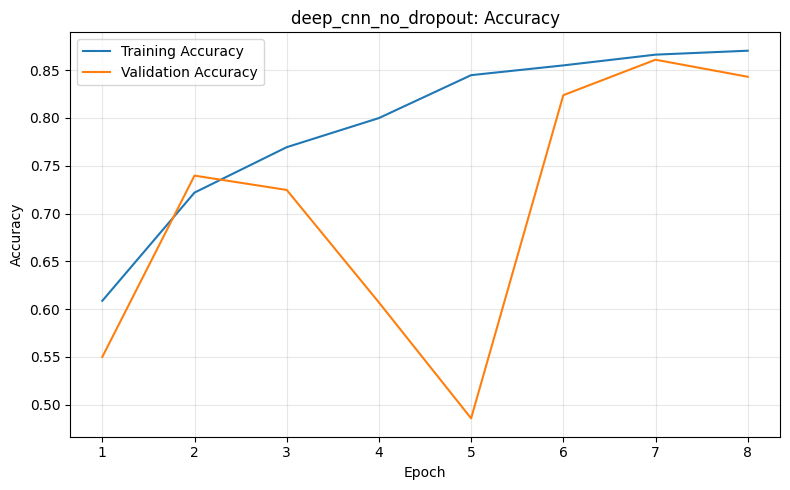

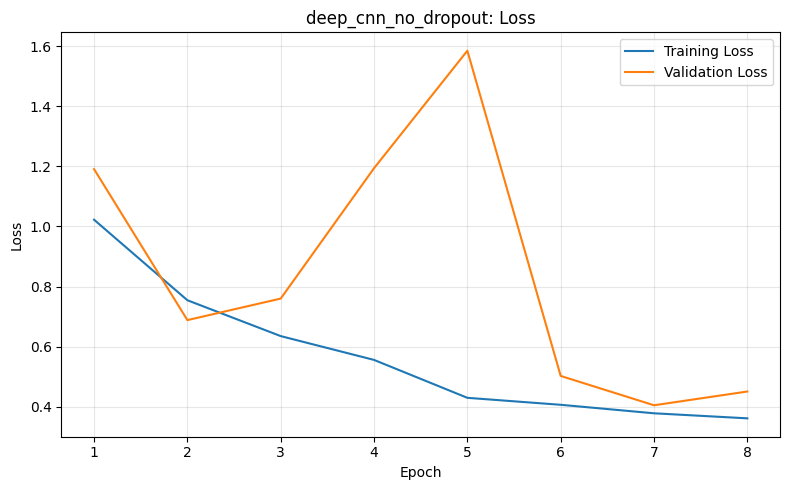

94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step

===== deep_cnn_no_dropout Evaluation =====
Accuracy:  0.8537
Precision: 0.8569
Recall:    0.8579
F1-score:  0.8551

              precision    recall  f1-score   support

   buildings       0.87      0.87      0.87       437
      forest       0.92      0.99      0.95       474
     glacier       0.86      0.72      0.78       553
    mountain       0.79      0.80      0.80       525
         sea       0.80      0.92      0.85       510
      street       0.91      0.85      0.88       501

    accuracy                           0.85      3000
   macro avg       0.86      0.86      0.86      3000
weighted avg       0.86      0.85      0.85      3000



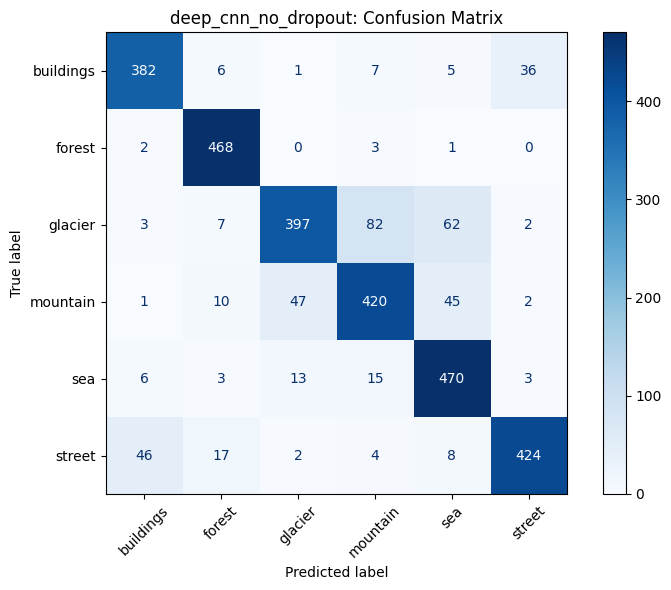

In [22]:
deep_no_dropout_history = train_and_time(
    deep_no_dropout_model,
    "deep_cnn_no_dropout",
    train_generator,
    val_generator,
    ABLATION_EPOCHS
)

plot_training_curves(deep_no_dropout_history, "deep_cnn_no_dropout")
deep_no_dropout_metrics, deep_no_dropout_predictions = evaluate_model(
    deep_no_dropout_model,
    test_generator,
    "deep_cnn_no_dropout"
)

## 10. Transfer learning with VGG16

This section uses VGG16 pretrained on ImageNet:
1. Feature extraction: freeze the convolutional base and train only the new classification head.
2. Fine-tuning: unfreeze the last VGG block and continue training with a very low learning rate.

A separate generator is used because VGG16 requires its own preprocessing function.

In [23]:
# =========================
# 10. TRANSFER LEARNING DATA GENERATORS
# =========================

from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input as vgg16_preprocess

tl_train_datagen = ImageDataGenerator(
    preprocessing_function=vgg16_preprocess,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode="nearest"
)

tl_eval_datagen = ImageDataGenerator(preprocessing_function=vgg16_preprocess)

tl_train_generator = tl_train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True,
    seed=SEED
)

tl_val_generator = tl_eval_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

tl_test_generator = tl_eval_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 12632 images belonging to 6 classes.
Found 1402 images belonging to 6 classes.
Found 3000 images belonging to 6 classes.


In [24]:
# =========================
# 10A. VGG16 FEATURE EXTRACTION
# =========================

def build_vgg16_transfer_model(input_shape=(150, 150, 3), num_classes=6):
    base_model = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )

    base_model.trainable = False

    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D(name="global_average_pooling")(x)
    x = Dense(256, activation="relu", name="custom_fc_1")(x)
    x = Dropout(0.40, name="custom_dropout")(x)
    outputs = Dense(num_classes, activation="softmax", name="output")(x)

    model = Model(inputs, outputs, name="vgg16_transfer_learning")

    model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model, base_model

vgg16_model, vgg16_base = build_vgg16_transfer_model(
    input_shape=(*IMG_SIZE, 3),
    num_classes=NUM_CLASSES
)

vgg16_model.summary()
print_model_size(vgg16_model, "vgg16_feature_extraction")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "vgg16_transfer_learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_fc_1 (Dense)             │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ custom_dropout (Dropout)        │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,558 (56.64 MB)

 Trainable params: 132,870 (519.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

vgg16_feature_extraction trainable parameters: 132,870
vgg16_feature_extraction non-trainable parameters: 14,714,688


Epoch 1/8
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.4413 - loss: 3.8476
Epoch 1: val_accuracy improved from None to 0.86591, saving model to outputs_2408454_AmanRauniyar/models/vgg16_feature_extraction_best.keras

Epoch 1: finished saving model to outputs_2408454_AmanRauniyar/models/vgg16_feature_extraction_best.keras
395/395 ━━━━━━━━━━━━━━━━━━━━ 125s 289ms/step - accuracy: 0.6045 - loss: 2.2912 - val_accuracy: 0.8659 - val_loss: 0.5602 - learning_rate: 1.0000e-04
Epoch 2/8
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.7791 - loss: 1.0049
Epoch 2: val_accuracy improved from 0.86591 to 0.88873, saving model to outputs_2408454_AmanRauniyar/models/vgg16_feature_extraction_best.keras

Epoch 2: finished saving model to outputs_2408454_AmanRauniyar/models/vgg16_feature_extraction_best.keras
395/395 ━━━━━━━━━━━━━━━━━━━━ 100s 254ms/step - accuracy: 0.7890 - loss: 0.9272 - val_accuracy: 0.8887 - val_loss: 0.4346 - learning_rate: 1.0000e-04
Epoch 3/8
395/395 ━━━━━━━━━━━

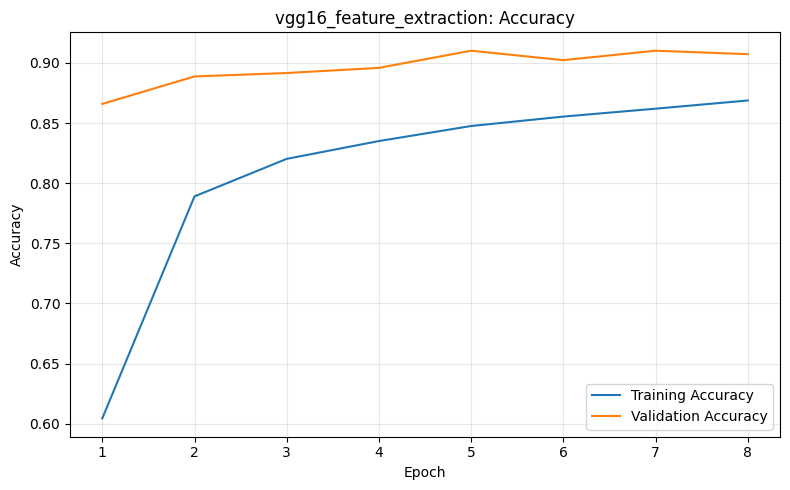

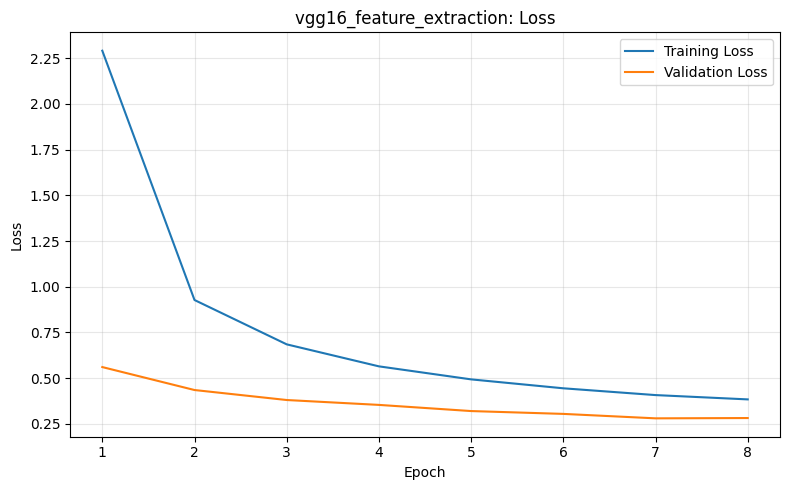

94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step

===== vgg16_feature_extraction Evaluation =====
Accuracy:  0.9047
Precision: 0.9061
Recall:    0.9071
F1-score:  0.9064

              precision    recall  f1-score   support

   buildings       0.90      0.90      0.90       437
      forest       0.99      0.99      0.99       474
     glacier       0.86      0.81      0.84       553
    mountain       0.85      0.86      0.85       525
         sea       0.92      0.97      0.94       510
      street       0.92      0.91      0.92       501

    accuracy                           0.90      3000
   macro avg       0.91      0.91      0.91      3000
weighted avg       0.90      0.90      0.90      3000



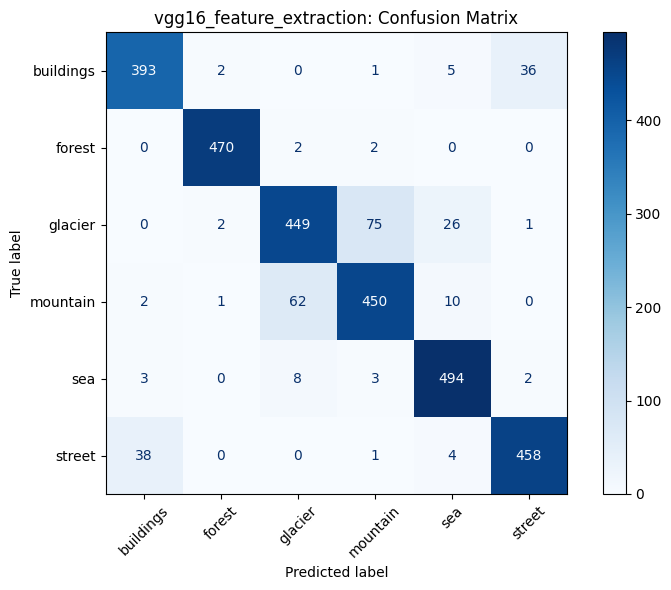

In [25]:
vgg16_feature_history = train_and_time(
    vgg16_model,
    "vgg16_feature_extraction",
    tl_train_generator,
    tl_val_generator,
    TL_FEATURE_EPOCHS
)

plot_training_curves(vgg16_feature_history, "vgg16_feature_extraction")
vgg16_feature_metrics, vgg16_feature_predictions = evaluate_model(
    vgg16_model,
    tl_test_generator,
    "vgg16_feature_extraction"
)

In [26]:
# =========================
# 10B. VGG16 FINE-TUNING
# =========================
# Unfreeze only VGG16 block5 layers for careful fine-tuning.
vgg16_base.trainable = True

for layer in vgg16_base.layers:
    if layer.name.startswith("block5"):
        layer.trainable = True
    else:
        layer.trainable = False

vgg16_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning trainable layers:")
for layer in vgg16_base.layers:
    if layer.trainable:
        print(layer.name)

print_model_size(vgg16_model, "vgg16_fine_tuned")

Fine-tuning trainable layers:
block5_conv1
block5_conv2
block5_conv3
block5_pool
vgg16_fine_tuned trainable parameters: 7,212,294
vgg16_fine_tuned non-trainable parameters: 7,635,264


Epoch 9/13
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.8625 - loss: 0.3883
Epoch 9: val_accuracy improved from None to 0.92154, saving model to outputs_2408454_AmanRauniyar/models/vgg16_fine_tuned_best.keras

Epoch 9: finished saving model to outputs_2408454_AmanRauniyar/models/vgg16_fine_tuned_best.keras
395/395 ━━━━━━━━━━━━━━━━━━━━ 113s 272ms/step - accuracy: 0.8780 - loss: 0.3630 - val_accuracy: 0.9215 - val_loss: 0.2385 - learning_rate: 1.0000e-05
Epoch 10/13
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.8984 - loss: 0.2885
Epoch 10: val_accuracy improved from 0.92154 to 0.92439, saving model to outputs_2408454_AmanRauniyar/models/vgg16_fine_tuned_best.keras

Epoch 10: finished saving model to outputs_2408454_AmanRauniyar/models/vgg16_fine_tuned_best.keras
395/395 ━━━━━━━━━━━━━━━━━━━━ 103s 261ms/step - accuracy: 0.8970 - loss: 0.2999 - val_accuracy: 0.9244 - val_loss: 0.2264 - learning_rate: 1.0000e-05
Epoch 11/13
395/395 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step -

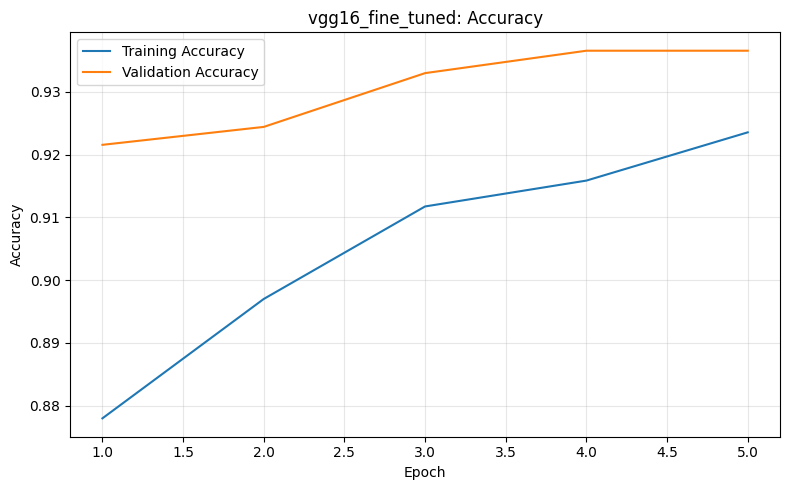

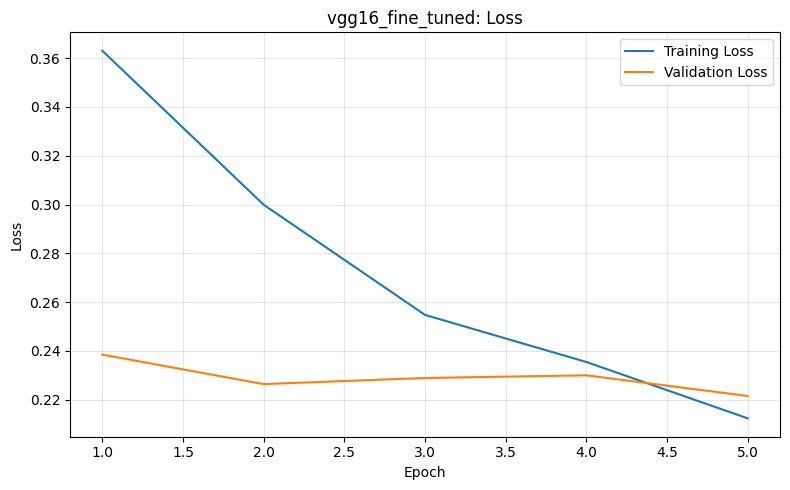

94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 118ms/step

===== vgg16_fine_tuned Evaluation =====
Accuracy:  0.9230
Precision: 0.9241
Recall:    0.9253
F1-score:  0.9245

              precision    recall  f1-score   support

   buildings       0.90      0.93      0.92       437
      forest       0.99      0.99      0.99       474
     glacier       0.89      0.85      0.87       553
    mountain       0.87      0.88      0.88       525
         sea       0.95      0.97      0.96       510
      street       0.95      0.92      0.94       501

    accuracy                           0.92      3000
   macro avg       0.92      0.93      0.92      3000
weighted avg       0.92      0.92      0.92      3000



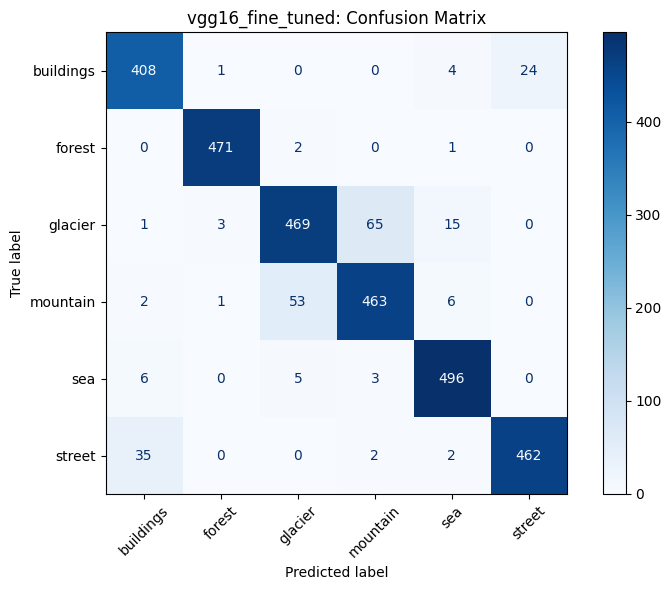

In [27]:
start = time.time()
vgg16_finetune_history = vgg16_model.fit(
    tl_train_generator,
    epochs=TL_FEATURE_EPOCHS + TL_FINE_TUNE_EPOCHS,
    initial_epoch=len(vgg16_feature_history.history["loss"]),
    validation_data=tl_val_generator,
    callbacks=make_callbacks("vgg16_fine_tuned"),
    verbose=1
)
fine_tune_time = time.time() - start

# Total VGG16 time = feature extraction + fine-tuning time
training_times["vgg16_fine_tuned"] = training_times.get("vgg16_feature_extraction", 0) + fine_tune_time
vgg16_model.save(MODEL_DIR / "vgg16_fine_tuned_final.keras")

print(f"Fine-tuning time only: {fine_tune_time:.2f} seconds ({fine_tune_time/60:.2f} minutes)")
print(f"Total VGG16 training time: {training_times['vgg16_fine_tuned']:.2f} seconds")

plot_training_curves(vgg16_finetune_history, "vgg16_fine_tuned")
vgg16_finetuned_metrics, vgg16_finetuned_predictions = evaluate_model(
    vgg16_model,
    tl_test_generator,
    "vgg16_fine_tuned"
)

## 11. Final comparison table

Use this table directly for your report after training.  
Do not write final conclusions until your own notebook has produced these values.

,model,test_accuracy,macro_precision,macro_recall,macro_f1,training_time_seconds,training_time_minutes
0,vgg16_fine_tuned,0.923000,0.924097,0.925337,0.924527,1381.171293,23.019522
1,vgg16_feature_extraction,0.904667,0.906093,0.907125,0.906356,857.903687,14.298395
2,baseline_cnn,0.866667,0.866865,0.869958,0.868011,1120.988660,18.683144
3,deep_cnn_adam,0.864667,0.866892,0.865242,0.864831,1244.613127,20.743552
4,deep_cnn_no_dropout,0.853667,0.856870,0.857877,0.855079,775.299452,12.921658
5,deep_cnn_sgd,0.757333,0.777359,0.759973,0.760552,1209.193768,20.153229



Best model based on test accuracy:


,model,test_accuracy,macro_precision,macro_recall,macro_f1,training_time_seconds,training_time_minutes
0,vgg16_fine_tuned,0.923,0.924097,0.925337,0.924527,1381.171293,23.019522


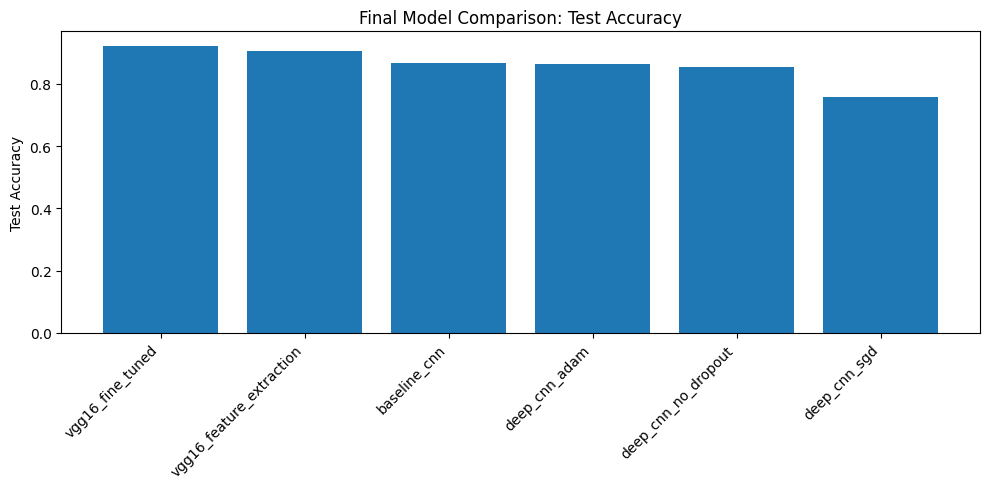

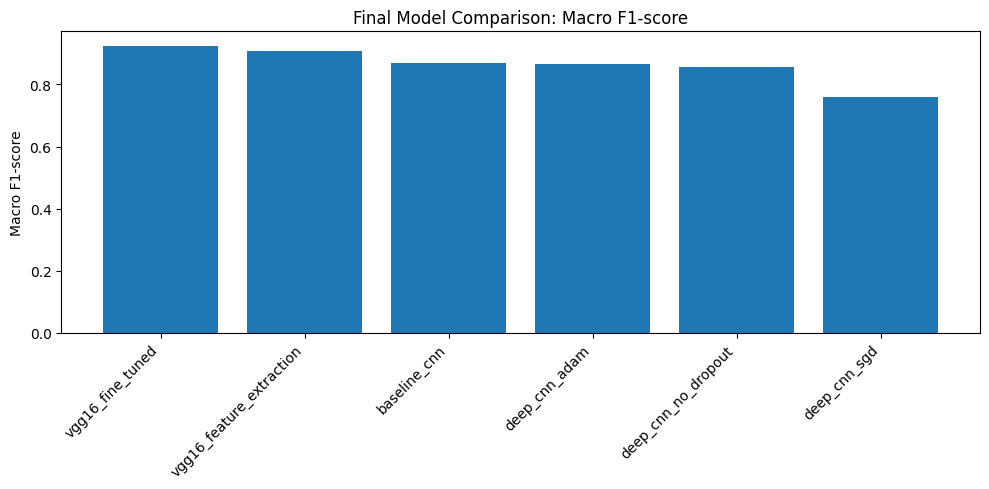

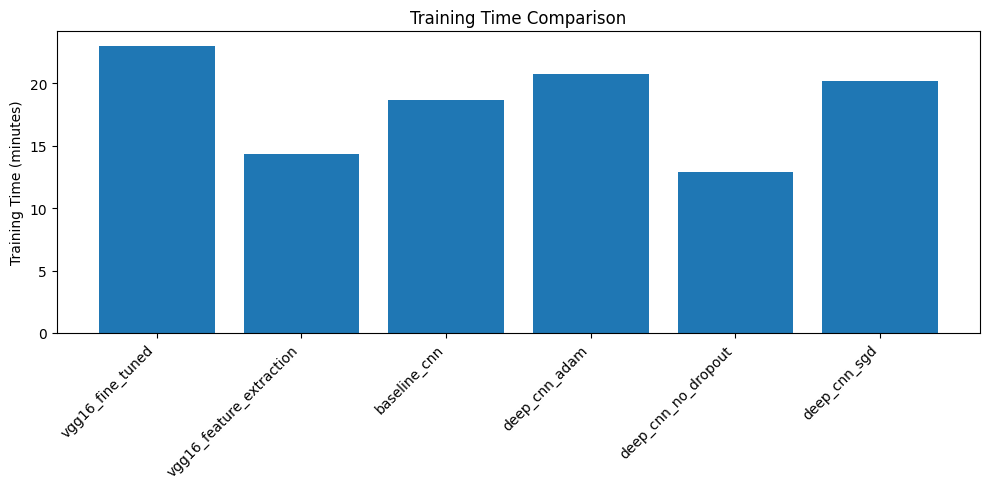

In [37]:
# =========================
# 11. FINAL MODEL COMPARISON
# =========================

results_df = pd.DataFrame(results).drop_duplicates(subset=["model"], keep="last")
results_df = results_df.sort_values(by="test_accuracy", ascending=False).reset_index(drop=True)

display(results_df)
results_df.to_csv(RESULT_DIR / "final_model_comparison.csv", index=False)

print("\nBest model based on test accuracy:")
display(results_df.head(1))

# Plot final comparison by accuracy and macro F1
plt.figure(figsize=(10, 5))
plt.bar(results_df["model"], results_df["test_accuracy"])
plt.title("Final Model Comparison: Test Accuracy")
plt.ylabel("Test Accuracy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "final_accuracy_comparison.png", dpi=150)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_df["model"], results_df["macro_f1"])
plt.title("Final Model Comparison: Macro F1-score")
plt.ylabel("Macro F1-score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "final_f1_comparison.png", dpi=150)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_df["model"], results_df["training_time_minutes"])
plt.title("Training Time Comparison")
plt.ylabel("Training Time (minutes)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "training_time_comparison.png", dpi=150)
plt.show()

## 12. Sample inference and error analysis

This section displays correct and incorrect predictions for viva explanation and report discussion.

Best model selected for inference: vgg16_fine_tuned


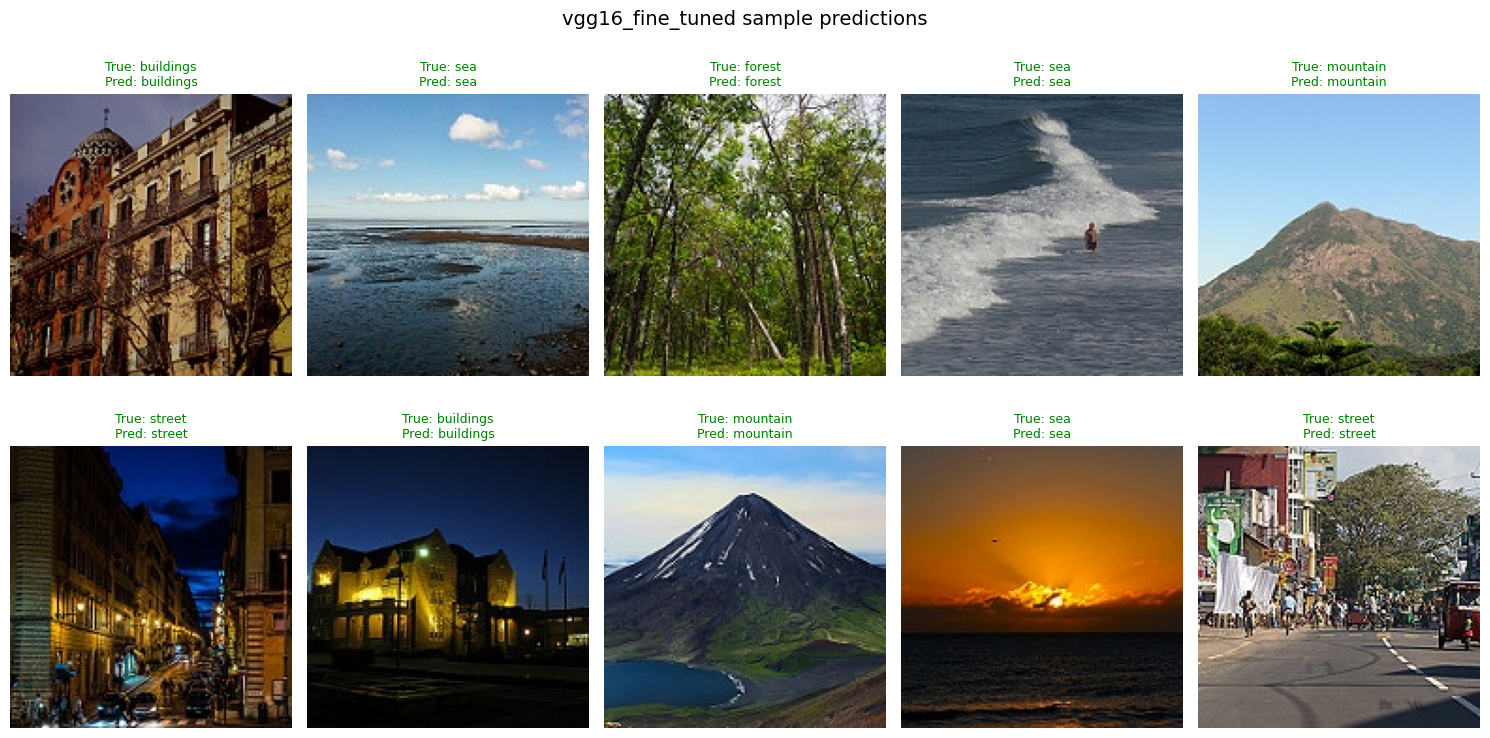

In [38]:
# =========================
# 12. SAMPLE INFERENCE AND ERROR ANALYSIS
# =========================

models_map = {
    "baseline_cnn": (baseline_model, "scratch"),
    "deep_cnn_adam": (deep_adam_model, "scratch"),
    "deep_cnn_sgd": (deep_sgd_model, "scratch"),
    "deep_cnn_no_dropout": (deep_no_dropout_model, "scratch"),
    "vgg16_feature_extraction": (vgg16_model, "vgg16"),  # after fine-tuning this object contains fine-tuned weights
    "vgg16_fine_tuned": (vgg16_model, "vgg16")
}

def preprocess_single_image(image_path, mode="scratch"):
    image = load_img(image_path, target_size=IMG_SIZE)
    arr = img_to_array(image)
    batch = np.expand_dims(arr, axis=0)

    if mode == "scratch":
        batch = batch / 255.0
    elif mode == "vgg16":
        batch = vgg16_preprocess(batch.copy())
    else:
        raise ValueError("mode must be 'scratch' or 'vgg16'")

    return image, batch

def show_predictions_from_files(model, mode, filepaths, title, n=10):
    sample_paths = random.sample(list(filepaths), min(n, len(filepaths)))
    plt.figure(figsize=(15, 8))

    for i, image_path in enumerate(sample_paths):
        raw_image, batch = preprocess_single_image(image_path, mode=mode)
        probs = model.predict(batch, verbose=0)[0]
        pred_idx = int(np.argmax(probs))
        pred_label = idx_to_class[pred_idx]

        true_label = Path(image_path).parent.name
        correct = pred_label == true_label

        plt.subplot(2, 5, i + 1)
        plt.imshow(raw_image)
        plt.title(
            f"True: {true_label}\nPred: {pred_label}",
            color="green" if correct else "red",
            fontsize=9
        )
        plt.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{title.lower().replace(' ', '_')}.png", dpi=150)
    plt.show()

# Choose the best available model after the comparison table has been created.
best_model_name = results_df.iloc[0]["model"]
best_model, best_mode = models_map[best_model_name]
print("Best model selected for inference:", best_model_name)

show_predictions_from_files(
    best_model,
    best_mode,
    test_generator.filepaths,
    title=f"{best_model_name} sample predictions",
    n=10
)

94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step


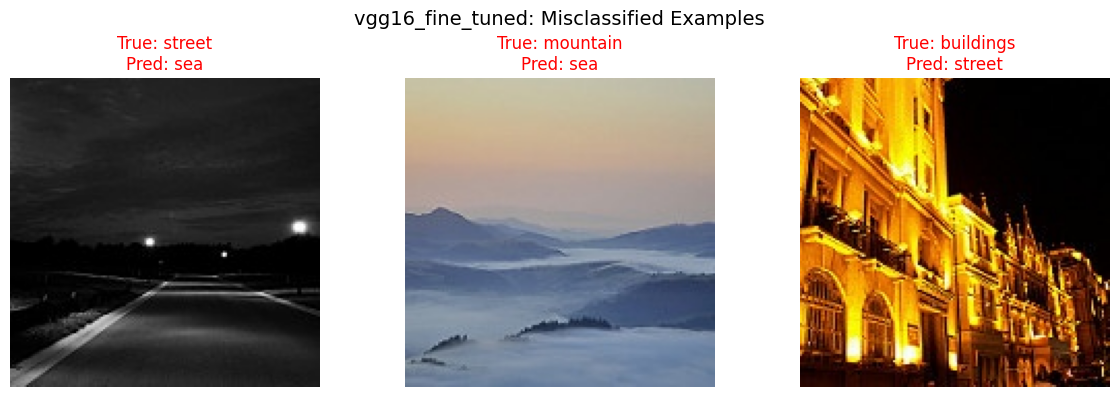

In [40]:
# Show 3 misclassified examples from the best model
def show_misclassified_examples(model, mode, generator, model_name, n=3):
    # For prediction alignment, use generator passed to the correct model mode.
    generator.reset()
    probs = model.predict(generator, verbose=1)
    y_pred = np.argmax(probs, axis=1)
    y_true = generator.classes
    labels = list(generator.class_indices.keys())

    wrong_indices = np.where(y_true != y_pred)[0]
    if len(wrong_indices) == 0:
        print("No misclassified examples found.")
        return

    sample_wrong = random.sample(list(wrong_indices), min(n, len(wrong_indices)))

    plt.figure(figsize=(12, 4))
    for i, idx in enumerate(sample_wrong):
        path = generator.filepaths[idx]
        raw_image, _ = preprocess_single_image(path, mode=mode)
        true_label = labels[y_true[idx]]
        pred_label = labels[y_pred[idx]]

        plt.subplot(1, len(sample_wrong), i + 1)
        plt.imshow(raw_image)
        plt.title(f"True: {true_label}\nPred: {pred_label}", color="red")
        plt.axis("off")

    plt.suptitle(f"{model_name}: Misclassified Examples", fontsize=14)
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{model_name}_misclassified_examples.png", dpi=150)
    plt.show()

# Use correct test generator for selected model
best_generator = tl_test_generator if best_mode == "vgg16" else test_generator
show_misclassified_examples(best_model, best_mode, best_generator, best_model_name, n=3)

## 13. Report-ready notes generated from the notebook

After running all training cells, this cell prints a compact summary for your report.  
Write the interpretation in your own words using your actual results.

In [41]:
# =========================
# 13. REPORT-READY SUMMARY
# =========================

print("Student: Aman Rauniyar (A)")
print("University ID: 2408454")
print("Dataset: Intel Natural Scene Image Classification")
print("Image size used:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Classes:", class_names)
print("\nDataset counts:")
display(dataset_counts)

print("\nFinal model comparison:")
display(results_df)

if "deep_cnn_adam" in results_df["model"].values and "baseline_cnn" in results_df["model"].values:
    baseline_acc = results_df.loc[results_df["model"] == "baseline_cnn", "test_accuracy"].iloc[0]
    deep_acc = results_df.loc[results_df["model"] == "deep_cnn_adam", "test_accuracy"].iloc[0]
    print(f"\nDeep CNN Adam vs Baseline accuracy difference: {deep_acc - baseline_acc:.4f}")

if "deep_cnn_sgd" in results_df["model"].values and "deep_cnn_adam" in results_df["model"].values:
    sgd_acc = results_df.loc[results_df["model"] == "deep_cnn_sgd", "test_accuracy"].iloc[0]
    adam_acc = results_df.loc[results_df["model"] == "deep_cnn_adam", "test_accuracy"].iloc[0]
    print(f"Adam vs SGD accuracy difference on deeper CNN: {adam_acc - sgd_acc:.4f}")

if "deep_cnn_no_dropout" in results_df["model"].values and "deep_cnn_adam" in results_df["model"].values:
    no_dropout_acc = results_df.loc[results_df["model"] == "deep_cnn_no_dropout", "test_accuracy"].iloc[0]
    dropout_acc = results_df.loc[results_df["model"] == "deep_cnn_adam", "test_accuracy"].iloc[0]
    print(f"Effect of Dropout accuracy difference: {dropout_acc - no_dropout_acc:.4f}")

if "vgg16_fine_tuned" in results_df["model"].values:
    tl_acc = results_df.loc[results_df["model"] == "vgg16_fine_tuned", "test_accuracy"].iloc[0]
    print(f"VGG16 fine-tuned test accuracy: {tl_acc:.4f}")

print("\nGenerated folders:")
print("Figures:", FIG_DIR)
print("Models:", MODEL_DIR)
print("Results:", RESULT_DIR)

Student: Aman Rauniyar (A)
University ID: 2408454
Dataset: Intel Natural Scene Image Classification
Image size used: (150, 150)
Batch size: 32
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

Dataset counts:


,split,class,count
0,train,buildings,1972
1,train,forest,2044
2,train,glacier,2164
3,train,mountain,2261
4,train,sea,2047
5,train,street,2144
6,val,buildings,219
7,val,forest,227
8,val,glacier,240
9,val,mountain,251



Final model comparison:


,model,test_accuracy,macro_precision,macro_recall,macro_f1,training_time_seconds,training_time_minutes
0,vgg16_fine_tuned,0.923000,0.924097,0.925337,0.924527,1381.171293,23.019522
1,vgg16_feature_extraction,0.904667,0.906093,0.907125,0.906356,857.903687,14.298395
2,baseline_cnn,0.866667,0.866865,0.869958,0.868011,1120.988660,18.683144
3,deep_cnn_adam,0.864667,0.866892,0.865242,0.864831,1244.613127,20.743552
4,deep_cnn_no_dropout,0.853667,0.856870,0.857877,0.855079,775.299452,12.921658
5,deep_cnn_sgd,0.757333,0.777359,0.759973,0.760552,1209.193768,20.153229



Deep CNN Adam vs Baseline accuracy difference: -0.0020
Adam vs SGD accuracy difference on deeper CNN: 0.1073
Effect of Dropout accuracy difference: 0.0110
VGG16 fine-tuned test accuracy: 0.9230

Generated folders:
Figures: outputs_2408454_AmanRauniyar/figures
Models: outputs_2408454_AmanRauniyar/models
Results: outputs_2408454_AmanRauniyar/results
